# Classical RK6 at dt = 0.8 versus the continuous-time networks

Loads the saved results of `rk6_comparison.py` (no recomputation) and shows the
comparison table and figure. Scored identically for all three: relative $L_2$
against the reference over the common step times $\{0, 0.8, \dots\} \le T$.

In [1]:
import pandas as pd
df = pd.read_csv('results/comparison_rel_l2.csv')
rk = df[df.variant == 'rk6_dt08'][['T', 'n_times', 'n_f_evals', 'finite', 'rel_l2']]
gl = df[df.variant == 'gl3_dt08'][['T', 'rel_l2']]
nets = (df[df.variant.isin(['plain', 'causal'])].groupby(['variant', 'T']).rel_l2
        .agg(['median', 'min', 'max']).reset_index())
print('explicit RK6, dt = 0.8 (not finite past t = 8.8):')
print(rk.to_string(index=False))
print('\nimplicit Gauss-Legendre q = 3 (order 6), dt = 0.8:')
print(gl.to_string(index=False))
print('\nnetworks at the same times (medians over 3 seeds):')
print(nets.to_string(index=False))

explicit RK6, dt = 0.8 (not finite past t = 8.8):
 T  n_times  n_f_evals  finite   rel_l2
 3        4       21.0    True 0.672930
 7        9       56.0    True 0.723283
14       18      119.0   False      NaN
27       34      231.0   False      NaN
40       51      350.0   False      NaN

implicit Gauss-Legendre q = 3 (order 6), dt = 0.8:
 T   rel_l2
 3 0.000063
 7 0.001195
14 0.003040
27 0.005359
40 0.008192

networks at the same times (medians over 3 seeds):
variant  T   median      min      max
 causal  3 0.000030 0.000028 0.000031
 causal  7 0.000087 0.000057 0.000134
 causal 14 0.000245 0.000114 0.770101
 causal 27 1.881023 0.878138 1.978768
 causal 40 2.025227 0.948843 2.250808
  plain  3 0.000033 0.000020 0.000044
  plain  7 0.000663 0.000453 0.004047
  plain 14 0.775409 0.770898 0.787103
  plain 27 0.896356 0.895116 0.897202
  plain 40 0.937112 0.932245 2.078008


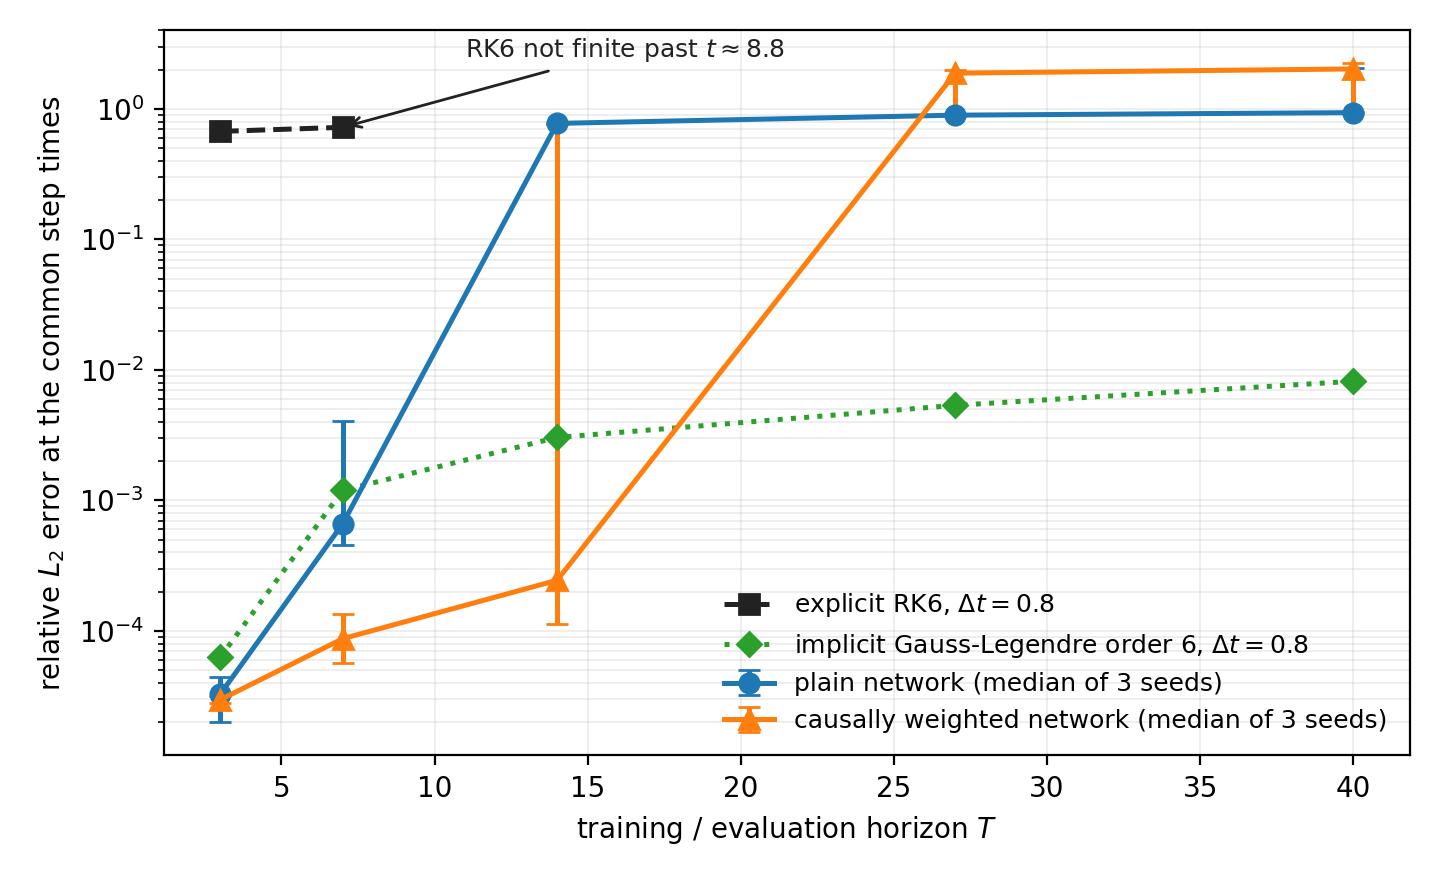

In [2]:
from IPython.display import Image
Image('figures/01_rk6_vs_pinn.png')

**Reading.** At the horizons where the networks work they are about four orders of
magnitude below the explicit order-6 method run at this step (T = 3: $3.3\times10^{-5}$
plain and $3.0\times10^{-5}$ causally weighted against $0.67$). The explicit method's
trajectory is order one from the first horizon and stops being finite at $t = 8.8$
(state $\sim 10^{21}$ at $t = 8.0$): dt = 0.8 lies outside its stable range on this
problem. The implicit Gauss-Legendre scheme of the discrete-time study takes the same
step at $2.4\times10^{-8}$ one-step error, which is the property the learned one-step
map inherits.

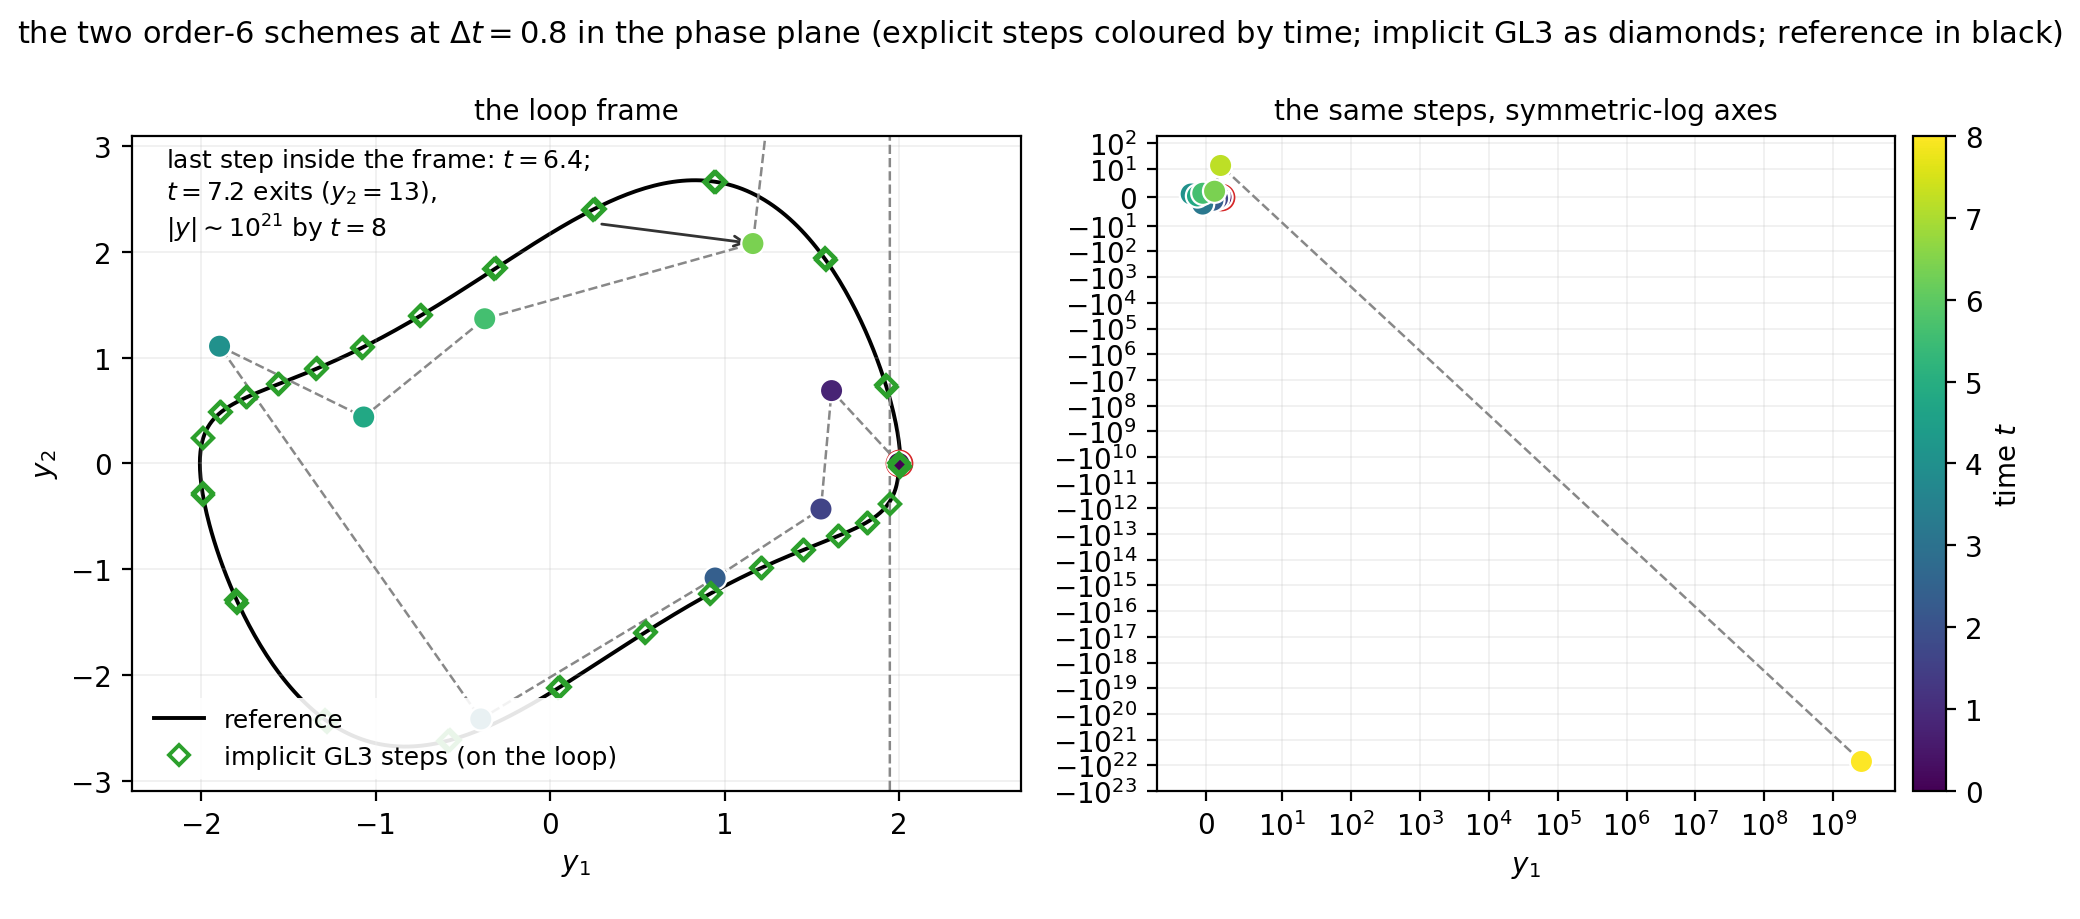

In [3]:
from IPython.display import Image
Image('figures/02_rk6_phase_plane.png')

**Phase plane.** Drawn as in the paper's phase-collapse figure (reference in black,
steps coloured by time, start in red). The first step already reverses the sign of the
velocity ($y_2 = +0.69$ where the reference has $-0.68$); the last step inside the loop
frame is $t = 6.4$, and the final excursion reaches $(2.6\times10^9, -7.1\times10^{21})$
at $t = 8$ (right panel, symmetric-log axes). The networks' failures collapse inward
toward the equilibrium; the explicit method at this step leaves the loop outward.

**Implicit counterpart.** The implicit member of the same order-6 family
(Gauss-Legendre, $q = 3$) at the same step is stable at every horizon,
$6.3\times10^{-5}$ at $T=3$ rising to $8.2\times10^{-3}$ at $T=40$; its steps sit on
the loop in the phase plane (open diamonds above). Within its working range the
causally weighted network is more accurate than the implicit scheme at the same step
($3.0\times10^{-5}$ vs $6.3\times10^{-5}$ at $T=3$; $8.7\times10^{-5}$ vs
$1.2\times10^{-3}$ at $T=7$; $2.5\times10^{-4}$ vs $3.0\times10^{-3}$ at $T=14$);
beyond two periods the implicit scheme is the only entry that still works.